In [1]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
import re
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Sequence, Dict
#from osgeo import gdal, osr, gdalconst, gdal_array

In [2]:
# functons for simple Matched Filter method
def get_wave_columns(df: pd.DataFrame) -> Tuple[list[str],np.ndarray]:
    wave_cols = []
    wavelengths = []
    pattern = re.compile(r"wave_([0-9.]+)nm")
    for col in df.columns:
        m = pattern.match(col)
        if m is not None:
            wave_cols.append(col)
            wavelengths.append(float(m.group(1)))

    wavelengths = np.array(wavelengths, dtype=float)

    order = np.argsort(wavelengths)
    wavelengths = wavelengths[order]
    wave_cols = [wave_cols[i] for i in order]

    return wave_cols, wavelengths

# read spectra from CSV file 
def load_roi_spectra_csv(path: str) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    df = pd.read_csv(path)
    if "y" not in df.columns or "x" not in df.columns:
        raise ValueError("y and x are required in the CSV file")
    
    wave_cols, wavelengths = get_wave_columns(df)
    if len(wave_cols) == 0:
        raise ValueError("No wavelength columns found in the CSV file")
    
    spectra =df[wave_cols].to_numpy(dtype=float)

    if not np.all(np.isfinite(spectra)):
                  raise ValueError("Spectra contain non-finite values")
    return df,wavelengths, spectra

# transform dataframe into image cube
def spectra_to_cube(
          df: pd.DataFrame,
          spectra: np.ndarray,
          full_value: float = np.nan
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
     ys = np.sort(df["y"].unique())
     xs = np.sort(df["x"].unique())

     y_to_i ={y: i for i, y in enumerate(ys)}
     x_to_j ={x: i for i, x in enumerate(xs)}

     H, W =len(ys), len(xs)
     B = spectra.shape[1]

     cube = np.full((H, W, B), full_value, dtype=float)

     for row_idx, row in df.iterrows():
          i = y_to_i[row["y"]]
          j = x_to_j[row["x"]]
          cube[i, j, :] =spectra[row_idx, :]

     return cube, ys, xs

# transform cube[H, W, B] into spectra[N_pixels, B]
def cube_to_spectra(cube: np.ndarray) -> np.ndarray:
     H, W, B = cube.shape
     return cube.reshape(H * W, B)

# select wavelengths ranges

# make a mask for wavelengths
def band_mask(
          wavelengths: np.ndarray,
          wl_min: Optional[float] = None,
          wl_max: Optional[float] = None,
          exclude_ranges: Optional[Sequence[Tuple[float,float]]] = None
) -> np.ndarray:
     mask = np.ones_like(wavelengths, dtype=bool)

     if wl_min is not None:
          mask &= wavelengths >= wl_min
     if wl_max is not None:
          mask &= wavelengths <= wl_max
     if exclude_ranges is not None:
        for a, b in exclude_ranges:
             mask &= ~((wavelengths >= a) & (wavelengths <= b))
     return mask 

# exclude wavelengths and select bands
def select_bands(
          cube: np.ndarray,
          wavelengths: np.ndarray,
          wl_min: float,
          wl_max:float,
          exclude_ranges: Optional[Sequence[tuple[float, float]]] = None 
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
     mask = band_mask(wavelengths, wl_min, wl_max, exclude_ranges)
     return cube[:, :, mask], wavelengths[mask], mask

# plot functions 

def plot_spectrum(
          wavelengths: np.ndarray,
          spectrum: np.ndarray,
          title: str = "Spectrum",
          xlim: Optional[Tuple[float, float]] = None 
):
     plt.figure(figsize=(8, 4))
     plt.plot(wavelengths, spectrum)
     plt.xlabel("Wavelength (nm)")
     plt.ylabel("Radiance/ Reflectance")
     plt.title(title)
     if xlim is not None:
          plt.xlim(*xlim)
     plt.grid(True)
     plt.show()

# plot seelected pixel's spectra
def plot_pixel_spectrum(
          cube: np.ndarray,
          wavelengths: np.ndarray,
          y: int,
          x: int,
          xlim: Optional[Tuple[float, float]] = None
):
     spectrum = cube[y, x, :]
     plot_spectrum(wavelengths, spectrum,title=f"Spectrum at y={y}, x={x}", xlim=xlim)

# plot all of roi or mean of mask spectra
def plot_mean_spectrum(
          cube: np.ndarray,
          wavelengths: np.ndarray,
          mask: Optional[np.ndarray] = None,
          xlim: Optional[Tuple[float, float]] = None
):
     if mask is None:
          spectra = cube.reshape(-1, cube.shape[-1])
     else:
          spectra = cube[mask]

     mean_spec = np.nanmean(spectra, axis=0)
     plot_spectrum(wavelengths, mean_spec, title="Mean Spectrum", xlim=xlim)

# plot the nearest band's image to thea target wavelength
def plot_band_image(
          cube: np.ndarray,
          wavelengths: np.ndarray,
          target_wl: float,
          title: Optional[str] = None 
):
     idx = int(np.argmin(np.abs(wavelengths - target_wl)))
     img = cube[:, :, idx]

     plt.figure(figsize=(5, 5))
     plt.imshow(img)
     plt.colorbar(label="Value")
     if title is None:
          title = f"Band image: {wavelengths[idx]:.2f} nm"
     plt.title(title)
     plt.xlabel("X")
     plt.ylabel("Y")    
     plt.show()

# background statistics

# estimate background mean and covariance
def estimate_background_mean_cov(
     spectra: np.ndarray,
     mask: Optional[np.ndarray] = None, # use only True pixels for estimation
     reg: float = 1e-6 # covariance regularization coefficient
) -> Tuple[np.ndarray, np.ndarray]:
    if mask is not None:
        X = spectra[mask]
    else:
        X = spectra

    mu = np.nanmean(X, axis=0) # background average spectrum
    Xc = X - mu
    cov = np.cov(Xc, rowvar=False) # background covatriance matrix
    cov = cov + reg * np.eye(cov.shape[0]) # numerical stabilization
    return mu, cov  

# improved version of estimate_background_mean_cov that can handle cube and mask
def estimate_background_mean_cov_from_cube(
    cube,
    valid_mask=None,
    reg=1e-6,
    min_pixels=None
):
    H, W, B = cube.shape

    if valid_mask is None:
        valid_mask = np.all(np.isfinite(cube), axis=2)

    X = cube[valid_mask]  # shape = (N_valid, B)

    good = np.all(np.isfinite(X), axis=1)
    X = X[good]

    if min_pixels is None:
        min_pixels = max(B + 5, 30)

    if X.shape[0] < min_pixels:
        raise ValueError(
            f"有効背景画素が少なすぎます: {X.shape[0]} pixels, "
            f"required >= {min_pixels}"
        )

    mu = np.mean(X, axis=0)

    Xc = X - mu
    cov = np.cov(Xc, rowvar=False)

    cov = cov + reg * np.eye(B)

    return mu, cov, X

# Caltulation of the inverse of the convariance matrix
def invert_cov(cov: np.ndarray, rcond: float = 1e-8)-> np.ndarray:
     return np.linalg.pinv(cov, rcond=rcond)

# -------------------------------Normal Matched Filter-------------------------------------------------------------------------
def matched_filter(
          spectra: np.ndarray,
          target: np.ndarray,
          mu: Optional[np.ndarray] = None,
          cov: Optional[np.ndarray] = None,
          background_mask: Optional[np.ndarray] = None, # pixels used for estimating background statistics
          reg: float = 1e-6 # converse regularization term for numerical stability
) -> np.ndarray:
     if mu is None or cov is None:
          mu, cov = estimate_background_mean_cov(
               spectra,
               mask=background_mask,
               reg=reg
          )
     inv_cov = invert_cov(cov)
     target = target.reshape(-1)
     diff = spectra -mu
     numerator = diff @ ( inv_cov @ target)
     denominator = target.T @ inv_cov @ target

     if np.abs(denominator) < 1e-12:
          raise ValueError("Denominator is too small, check the target spectrum and covariance matrix.")
     
     alpha = numerator / denominator
     return alpha

# apply matched filter to the whole cube and return alpha map, background mean and covariance
def matched_filter_map_from_cube(
    cube,
    uas,
    valid_mask=None,
    reg=1e-6,
    background_mask=None
):
    H, W, B = cube.shape

    if valid_mask is None:
        valid_mask = np.all(np.isfinite(cube), axis=2)

    if background_mask is None:
        background_mask = valid_mask
    else:
        background_mask = background_mask & valid_mask

    mu, cov, _ = estimate_background_mean_cov_from_cube(
        cube,
        valid_mask=background_mask,
        reg=reg
    )

    target = -mu * uas

    inv_cov = np.linalg.pinv(cov)

    alpha_map = np.full((H, W), np.nan, dtype=float)

    X = cube[valid_mask]
    diff = X - mu

    numerator = diff @ inv_cov @ target
    denominator = target.T @ inv_cov @ target

    if np.abs(denominator) < 1e-12:
        raise ValueError("Denominator is too small, check the target spectrum and covariance matrix.")

    alpha_values = numerator / denominator

    alpha_map[valid_mask] = alpha_values

    return alpha_map, mu, cov

# transform alpha[N_pixels] into alpha_map[H, W]
def alpha_to_map(alpha: np.ndarray, H: int, W: int) -> np.ndarray:
     return alpha.reshape(H, W)

def plot_alpha_map(
          alpha_map: np.ndarray,
          title: str = "Matched Filter Output",
          vmin: Optional[float] = None,
          vmax: Optional[float] = None
):
     plt.figure(figsize=(5, 5))
     plt.imshow(alpha_map, vmin=vmin, vmax=vmax)
     plt.colorbar(label=r"$\hat{\alpha}$")
     plt.title(title)
     plt.xlabel("x")
     plt.ylabel("y")
     plt.show()

# target spectrum create assistance

# make target spectrum t by background mean spectrum mu and UAS s 
# Beer-Lambert Law
def make_target_from_uas(
          mu: np.ndarray,
          uas: np.ndarray,
          sign: float = -1.0
) ->np.ndarray:
    return sign * mu * uas

# appoximate UAS from two simulation spectra
def finite_difference_uas(
          L0: np.ndarray,
          L1: np.ndarray,
          delta_alpha: float
) -> np.ndarray:
     eps = 1e-12
     ratio = np.clip(L1 / np.maximum(L0, eps), eps, None)
     uas = -np.log(ratio) / delta_alpha
     return uas

In [3]:
#additional functions 

# scale image for visualization by robust scaling
def robust_scale_image(img: np.ndarray, pmin: float = 2, pmax: float = 98) -> np.ndarray:
    lo, hi = np.nanpercentile(img, [pmin, pmax])
    if hi <= lo:
        return np.zeros_like(img)
    return np.clip((img - lo) / (hi - lo), 0, 1)

# make RGB image from cube by selecting the nearest bands to the target wavelengths for R, G, B
def make_rgb_from_cube(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    r_wl: float = 650,
    g_wl: float = 550,
    b_wl: float = 460
) -> np.ndarray:
    idx_r = int(np.argmin(np.abs(wavelengths - r_wl)))
    idx_g = int(np.argmin(np.abs(wavelengths - g_wl)))
    idx_b = int(np.argmin(np.abs(wavelengths - b_wl)))

    r = robust_scale_image(cube[:, :, idx_r])
    g = robust_scale_image(cube[:, :, idx_g])
    b = robust_scale_image(cube[:, :, idx_b])

    rgb = np.dstack([r, g, b])
    return rgb

# add scale bar to image axes
def add_scalebar(
    ax,
    image_shape,
    pixel_size_m: float = 20,
    scale_length_m: float = 1000,
    location: str = "lower right",
    margin_px: int = 12,
    bar_height_px: int = 4,
    color: str = "white",
    outline_color: str = "black",
    fontsize: int = 11
):
    """
    Add a scale bar to an image.

    Parameters
    ----------
    ax : matplotlib axis
        Axis on which the image is plotted.
    image_shape : tuple
        Image shape. Either (H, W) or (H, W, C).
    pixel_size_m : float
        Ground sampling distance [m/pixel].
    scale_length_m : float
        Scale bar length [m].
    location : str
        Currently supports "lower right".
    """
    import matplotlib.patheffects as pe

    H, W = image_shape[:2]
    scale_length_px = scale_length_m / pixel_size_m

    if scale_length_px > W:
        raise ValueError("scale_length_m is longer than image width.")

    if location != "lower right":
        raise ValueError('Only location="lower right" is currently supported.')

    x1 = W - margin_px
    x0 = x1 - scale_length_px
    y = H - margin_px

    # thick white bar with black outline so that it is visible on bright/dark backgrounds
    ax.plot(
        [x0, x1],
        [y, y],
        color=color,
        linewidth=bar_height_px,
        solid_capstyle="butt",
        path_effects=[
            pe.Stroke(linewidth=bar_height_px + 2, foreground=outline_color),
            pe.Normal()
        ]
    )

    # label
    if scale_length_m >= 1000:
        label = f"{scale_length_m / 1000:g} km"
    else:
        label = f"{scale_length_m:g} m"

    ax.text(
        (x0 + x1) / 2,
        y - 8,
        label,
        color=color,
        fontsize=fontsize,
        ha="center",
        va="bottom",
        path_effects=[
            pe.Stroke(linewidth=2.5, foreground=outline_color),
            pe.Normal()
        ]
    )

# plot RGB image
def plot_rgb(
    rgb: np.ndarray,
    title: str = "RGB",
    pixel_size_m: float = 20,
    scale_length_m: float = 1000,
    show_scalebar: bool = True
):
    plt.figure(figsize=(5, 5))
    ax = plt.gca()
    ax.imshow(rgb)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if show_scalebar:
        add_scalebar(
            ax,
            rgb.shape,
            pixel_size_m=pixel_size_m,
            scale_length_m=scale_length_m,
            location="lower right"
        )

    plt.show()


In [4]:
# robust thresholding for alpha map to exclude high alpha pixels from background estimation
def robust_threshold_from_alpha(alpha_values, nsigma=3.0):
    alpha_values = alpha_values[np.isfinite(alpha_values)]

    if alpha_values.size == 0:
        raise ValueError("No finite alpha values for thresholding.")

    med = np.nanmedian(alpha_values)
    mad = np.nanmedian(np.abs(alpha_values - med))

    robust_std = 1.4826 * mad + 1e-12
    threshold = med + nsigma * robust_std

    return threshold, med, robust_std

In [5]:
# load MODTRAN spectra from CSV file
def load_ch4_modtran_csv(path):
    df_mod = pd.read_csv(path)

    if "wavelength" not in df_mod.columns:
        raise ValueError(" wavelength column is required in the MODTRAN CSV file.")

    mod_wave = df_mod["wavelength"].to_numpy(dtype=float)

    alpha_cols = [c for c in df_mod.columns if c != "wavelength"]

    try:
        alpha_grid = np.array([float(c) for c in alpha_cols], dtype=float)
    except ValueError:
        raise ValueError(" modtran CSV column names other than 'wavelength' must be numeric values representing alpha.")

    order = np.argsort(alpha_grid)
    alpha_grid = alpha_grid[order]
    alpha_cols = [alpha_cols[i] for i in order]

    # shape = (N_alpha, N_wave)
    mod_spectra = df_mod[alpha_cols].to_numpy(dtype=float).T

    if not np.all(np.isfinite(mod_spectra)):
        raise ValueError("MODTRAN spectra contain NaN or inf values.")

    return mod_wave, alpha_grid, mod_spectra

# resample MODTRAN spectra to sensor wavelengths using Gaussian SRF
def gaussian_srf_resample(mod_wave, mod_spectra, sensor_wave, fwhm_nm):
    mod_wave = np.asarray(mod_wave)
    sensor_wave = np.asarray(sensor_wave)

    if np.isscalar(fwhm_nm):
        fwhm_arr = np.full_like(sensor_wave, float(fwhm_nm), dtype=float)
    else:
        fwhm_arr = np.asarray(fwhm_nm, dtype=float)
        if len(fwhm_arr) != len(sensor_wave):
            raise ValueError("fwhm_nm must be a scalar or an array of the same length as sensor_wave.")

    out = np.zeros((mod_spectra.shape[0], len(sensor_wave)), dtype=float)

    for j, center in enumerate(sensor_wave):
        sigma = fwhm_arr[j] / (2.0 * np.sqrt(2.0 * np.log(2.0)))

        use = np.abs(mod_wave - center) <= 4.0 * sigma # consider wavelengths within 4 sigma

        if np.sum(use) < 2:
            out[:, j] = np.interp(center, mod_wave, mod_spectra)
            continue

        w = np.exp(-0.5 * ((mod_wave[use] - center) / sigma) ** 2)
        w = w / np.sum(w)

        out[:, j] = mod_spectra[:, use] @ w

    return out

# make Ch4 UAS from MODTRAN spectra by log-slope method or finite difference method

def compute_uas_log_slope(alpha_grid, spectra_grid, alpha_min=None, alpha_max=None):
    alpha_grid = np.asarray(alpha_grid, dtype=float)
    spectra_grid = np.asarray(spectra_grid, dtype=float)

    use = np.ones_like(alpha_grid, dtype=bool)

    if alpha_min is not None:
        use &= alpha_grid >= alpha_min
    if alpha_max is not None:
        use &= alpha_grid <= alpha_max

    a = alpha_grid[use]
    Y = np.log(np.maximum(spectra_grid[use], 1e-30))  # shape = (N_use, N_band)

    if len(a) < 2:
        raise ValueError("Not enough alpha points in the specified range for log-slope method.")

    # For each band, fit ln L = intercept + slope * alpha by least squares
    A = np.vstack([np.ones_like(a), a]).T  # shape = (N_use, 2)

    # coeff shape = (2, N_band)
    coeff, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)

    intercept = coeff[0]
    slope = coeff[1]

    uas = -slope

    return uas, intercept

# compute UAS by finite difference method using two spectra at specified alpha values
def compute_uas_two_spectra(alpha_grid, spectra_grid, alpha_ref=0.0, alpha_pert=1.0):
    idx_ref = int(np.argmin(np.abs(alpha_grid - alpha_ref)))
    idx_pert = int(np.argmin(np.abs(alpha_grid - alpha_pert)))

    a0 = alpha_grid[idx_ref]
    a1 = alpha_grid[idx_pert]

    if np.isclose(a1, a0):
        raise ValueError("alpha_ref and alpha_pert are too close, cannot compute finite difference UAS.")

    L0 = spectra_grid[idx_ref]
    L1 = spectra_grid[idx_pert]

    ratio = np.maximum(L1, 1e-30) / np.maximum(L0, 1e-30)
    uas = -np.log(ratio) / (a1 - a0)

    return uas

# make target spectrum t by background mean spectrum mu and UAS s
def make_methane_target(mu, uas, positive_alpha=True):
    if positive_alpha:
        return -mu * uas
    else:
        return mu * uas
    
# plot functions for UAS and target spectrum
def plot_uas(wavelengths, uas, title="CH4 UAS", xlim=None):
    plt.figure(figsize=(8, 4))
    plt.plot(wavelengths, uas)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("UAS")
    plt.title(title)
    if xlim is not None:
        plt.xlim(*xlim)
    plt.grid(True)
    plt.show()


def plot_target(wavelengths, target, title="MF target spectrum", xlim=None):
    plt.figure(figsize=(8, 4))
    plt.plot(wavelengths, target)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("target")
    plt.title(title)
    if xlim is not None:
        plt.xlim(*xlim)
    plt.grid(True)
    plt.show()

# plot MODTRAN spectra for selected alpha values
def compare_modtran_spectra(wavelengths, alpha_grid, spectra_grid, alpha_list=None, xlim=None):
    if alpha_list is None:
        alpha_list = [alpha_grid[0], alpha_grid[len(alpha_grid)//2], alpha_grid[-1]]

    plt.figure(figsize=(8, 4))

    for a in alpha_list:
        idx = int(np.argmin(np.abs(alpha_grid - a)))
        plt.plot(wavelengths, spectra_grid[idx], label=f"alpha={alpha_grid[idx]:g}")

    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Radiance")
    plt.title("MODTRAN CH4 spectra")
    if xlim is not None:
        plt.xlim(*xlim)
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
# iterative matched filter map estimation by excluding high alpha pixels from background estimation and re-estimating background statistics
def iterative_matched_filter_map_from_cube(
    cube,
    uas,
    valid_mask=None,
    initial_background_mask=None,
    n_iter=5,
    nsigma=5.0,
    reg=1e-6,
    rcond=1e-8,
    min_background_pixels=None,
    verbose=True
):

    H, W, B = cube.shape
    uas = np.asarray(uas, dtype=float).reshape(-1)

    if uas.shape[0] != B:
        raise ValueError(f"uas length {uas.shape[0]} does not match cube bands {B}.")

    if valid_mask is None:
        valid_mask = np.all(np.isfinite(cube), axis=2)

    valid_mask = valid_mask.astype(bool)

    if initial_background_mask is None:
        background_mask = valid_mask.copy()
    else:
        background_mask = initial_background_mask.astype(bool) & valid_mask

    if min_background_pixels is None:
        min_background_pixels = max(B + 5, 30)

    alpha_history = []
    plume_mask_history = []
    background_mask_history = []
    threshold_history = []
    mu_history = []
    cov_history = []

    prev_plume_mask = None

    for it in range(n_iter):
        n_bg = int(np.sum(background_mask))

        if n_bg < min_background_pixels:
            raise ValueError(
                f"Background pixels are too few at iter {it + 1}: "
                f"{n_bg} pixels, required >= {min_background_pixels}"
            )

        # 1. Estimate background statistics
        mu, cov, _ = estimate_background_mean_cov_from_cube(
            cube,
            valid_mask=background_mask,
            reg=reg,
            min_pixels=min_background_pixels
        )

        # 2. Update MF target using current background mean
        target = make_methane_target(
            mu=mu,
            uas=uas,
            positive_alpha=True
        )

        # 3. Apply MF to valid pixels
        inv_cov = np.linalg.pinv(cov, rcond=rcond)

        alpha_map = np.full((H, W), np.nan, dtype=float)

        X = cube[valid_mask]
        diff = X - mu

        numerator = diff @ inv_cov @ target
        denominator = target.T @ inv_cov @ target

        if np.abs(denominator) < 1e-12:
            raise ValueError("Denominator is too small. Check target spectrum and covariance.")

        alpha_values = numerator / denominator
        alpha_map[valid_mask] = alpha_values

        # 4. Detect plume candidates
        threshold, med, robust_std = robust_threshold_from_alpha(
            alpha_map[valid_mask],
            nsigma=nsigma
        )

        plume_mask = np.zeros((H, W), dtype=bool)
        plume_mask[valid_mask] = alpha_map[valid_mask] > threshold

        # 5. Update background mask by excluding plume candidates
        new_background_mask = valid_mask & (~plume_mask)

        # Save histories
        alpha_history.append(alpha_map.copy())
        plume_mask_history.append(plume_mask.copy())
        background_mask_history.append(background_mask.copy())
        threshold_history.append(threshold)
        mu_history.append(mu.copy())
        cov_history.append(cov.copy())

        if verbose:
            print(
                f"iter {it + 1:02d}: "
                f"background={n_bg}, "
                f"threshold={threshold:.6g}, "
                f"median={med:.6g}, "
                f"robust_std={robust_std:.6g}, "
                f"plume_pixels={int(np.sum(plume_mask))}"
            )

        # 6. Stop if plume mask converged
        if prev_plume_mask is not None:
            if np.array_equal(plume_mask, prev_plume_mask):
                if verbose:
                    print(f"Converged at iter {it + 1}.")
                background_mask = new_background_mask
                break

        prev_plume_mask = plume_mask.copy()
        background_mask = new_background_mask

    result = {
        "alpha_map": alpha_history[-1],
        "plume_mask": plume_mask_history[-1],
        "background_mask": background_mask,
        "alpha_history": alpha_history,
        "plume_mask_history": plume_mask_history,
        "background_mask_history": background_mask_history,
        "threshold_history": threshold_history,
        "mu_history": mu_history,
        "cov_history": cov_history,
    }

    return result

(40000, 187)
(200, 200, 185)
405.0 2474.76


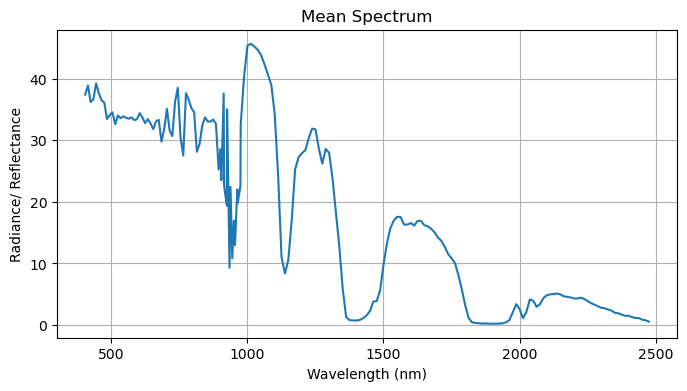

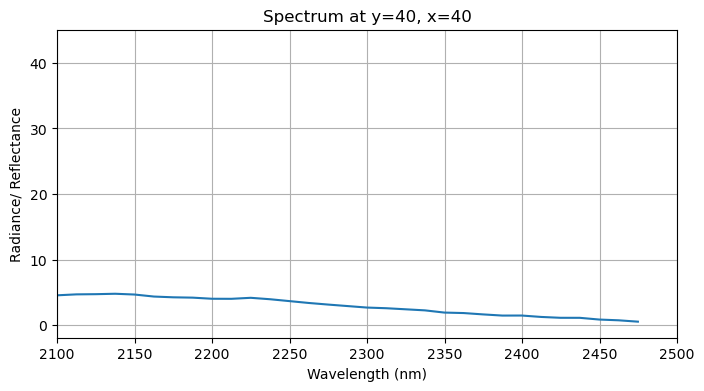

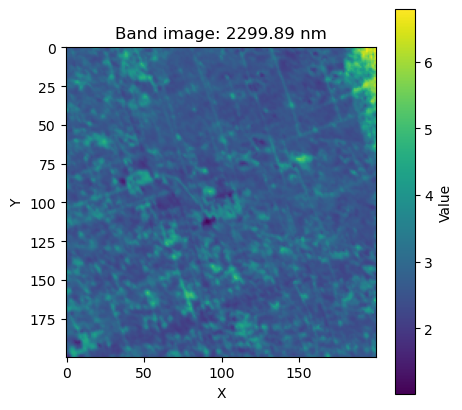

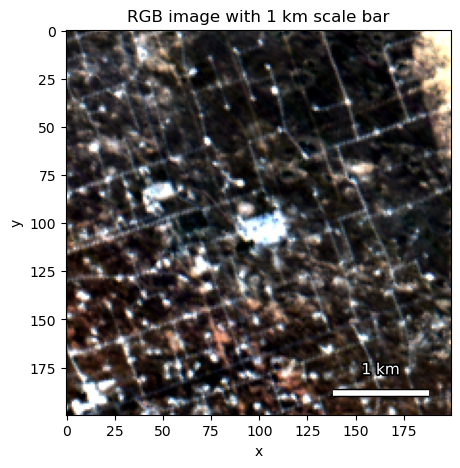

MODTRAN wave: 380.0 2500.0 2121
alpha_grid: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]
mod_spectra: (26, 2121)


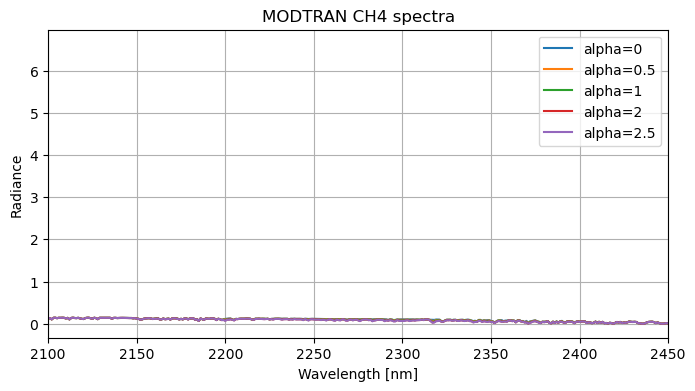

In [11]:
path = r"D:\research\code\all_roi_spectra200x200.csv"

df, wavelengths, spectra = load_roi_spectra_csv(path)
cube, ys, xs = spectra_to_cube(df, spectra)

print(df.shape)
print(cube.shape)
print(wavelengths[0], wavelengths[-1])

plot_mean_spectrum(cube, wavelengths)
plot_pixel_spectrum(cube, wavelengths, y=40, x=40, xlim=(2100, 2500))
plot_band_image(cube, wavelengths, target_wl=2300)

rgb = make_rgb_from_cube(cube, wavelengths)
plot_rgb(rgb, title="RGB image with 1 km scale bar")
ch4_path = r"E:\refit\CH4c.csv"

mod_wave, alpha_grid, mod_spectra = load_ch4_modtran_csv(ch4_path)

print("MODTRAN wave:", mod_wave[0], mod_wave[-1], len(mod_wave))
print("alpha_grid:", alpha_grid)
print("mod_spectra:", mod_spectra.shape)

compare_modtran_spectra(
    mod_wave,
    alpha_grid,
    mod_spectra,
    alpha_list=[0, 0.5, 1.0, 2.0, 2.5],
    xlim=(2100, 2450)
)


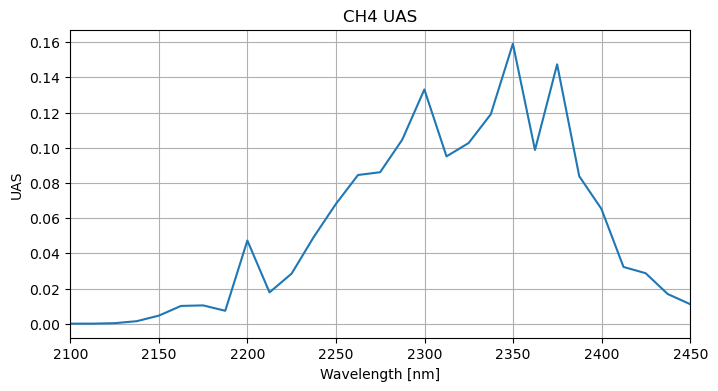

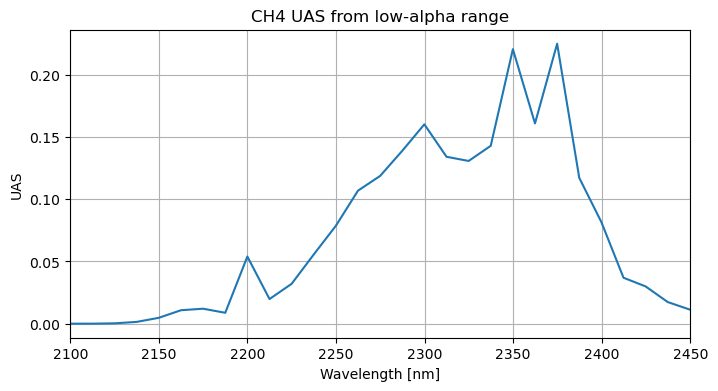

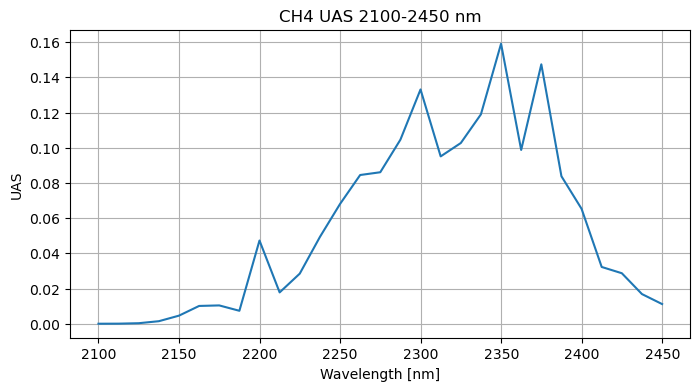

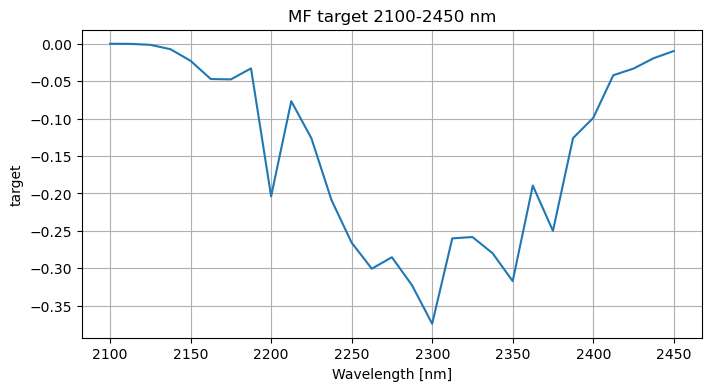

In [12]:
mod_sensor = gaussian_srf_resample(
    mod_wave=mod_wave,
    mod_spectra=mod_spectra,
    sensor_wave=wavelengths,
    fwhm_nm=12.5
)
uas_all, intercept = compute_uas_log_slope(
    alpha_grid=alpha_grid,
    spectra_grid=mod_sensor,
    alpha_min=0.0,
    alpha_max=2.5
)

plot_uas(wavelengths, uas_all, xlim=(2100, 2450))
uas_low, _ = compute_uas_log_slope(
    alpha_grid=alpha_grid,
    spectra_grid=mod_sensor,
    alpha_min=0.0,
    alpha_max=0.5
)

plot_uas(wavelengths, uas_low, title="CH4 UAS from low-alpha range", xlim=(2100, 2450))
cube_2300, wave_2300, mask_2300 = select_bands(
    cube,
    wavelengths,
    wl_min=2100,
    wl_max=2450
)

spectra_2300 = cube_to_spectra(cube_2300)

uas_2300 = uas_all[mask_2300]

mu_2300, cov_2300 = estimate_background_mean_cov(
    spectra_2300,
    mask=None,
    reg=1e-6
)

# MF target
target_2300 = make_methane_target(
    mu=mu_2300,
    uas=uas_2300,
    positive_alpha=True
)

plot_uas(wave_2300, uas_2300, title="CH4 UAS 2100-2450 nm")
plot_target(wave_2300, target_2300, title="MF target 2100-2450 nm")

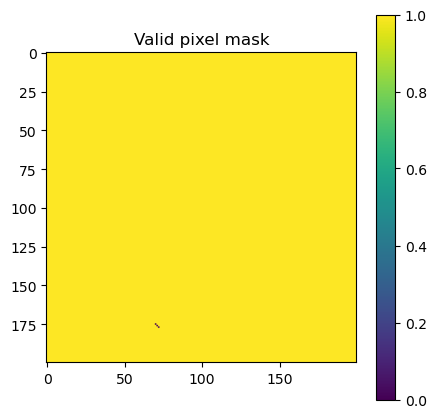

In [13]:
# invalid mask check

def make_valid_pixel_mask(
    cube,
    nodata_values=None,
    require_positive=True,
    min_valid_fraction=1.0
):
    H, W, B = cube.shape

    finite = np.isfinite(cube)

    valid_band = finite.copy()

    if nodata_values is not None:
        for v in nodata_values:
            valid_band &= cube != v

    if require_positive:
        valid_band &= cube > 0

    valid_fraction = np.mean(valid_band, axis=2)

    valid_mask = valid_fraction >= min_valid_fraction

    return valid_mask

valid_mask = make_valid_pixel_mask(
    cube,
    nodata_values=[0, -9999],
    require_positive=True,
    min_valid_fraction=1.0
)

plt.figure(figsize=(5, 5))
plt.imshow(valid_mask)
plt.title("Valid pixel mask")
plt.colorbar()
plt.show()

In [26]:
cube_2300, wave_2300, mask_2300 = select_bands(
    cube,
    wavelengths,
    wl_min=2100,
    wl_max=2450
)

uas_2300 = uas_low[mask_2300]

# make valid mask for cube_2300
valid_mask_2300 = make_valid_pixel_mask(
    cube_2300,
    nodata_values=[0, -9999],
    require_positive=True,
    min_valid_fraction=1.0
)

# apply matched filter to the cube and get alpha map, background mean and covariance
alpha_map, mu_2300, cov_2300 = matched_filter_map_from_cube(
    cube=cube_2300,
    uas=uas_2300,
    valid_mask=valid_mask_2300,
    reg=1e-6
)
result_imf = iterative_matched_filter_map_from_cube(
    cube=cube_2300,
    uas=uas_2300,
    valid_mask=valid_mask_2300,
    initial_background_mask=None,
    n_iter=5,
    nsigma=4.0,
    reg=1e-6,
    verbose=True
)

alpha_imf_map = result_imf["alpha_map"]
plume_imf_mask = result_imf["plume_mask"]
background_imf_mask = result_imf["background_mask"]

iter 01: background=40000, threshold=0.135677, median=-6.40929e-05, robust_std=0.0339352, plume_pixels=15
iter 02: background=39985, threshold=0.128413, median=-0.000284775, robust_std=0.0321745, plume_pixels=48
iter 03: background=39952, threshold=0.127492, median=-0.000157545, robust_std=0.0319124, plume_pixels=64
iter 04: background=39936, threshold=0.127204, median=-0.000139174, robust_std=0.0318357, plume_pixels=70
iter 05: background=39930, threshold=0.127095, median=-0.000115754, robust_std=0.0318027, plume_pixels=74


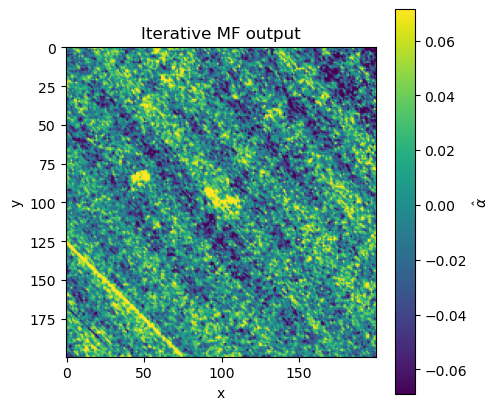

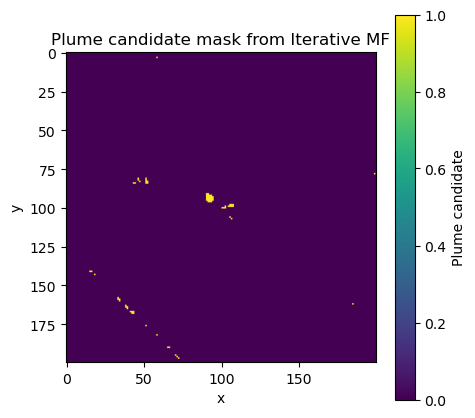

In [27]:
# plot iterative MF result
plot_alpha_map(
    alpha_imf_map,
    title="Iterative MF output",
    vmin=np.nanpercentile(alpha_imf_map, 2),
    vmax=np.nanpercentile(alpha_imf_map, 98)
)
# plot plume candidate mask from iterative MF
plt.figure(figsize=(5, 5))
plt.imshow(plume_imf_mask)
plt.title("Plume candidate mask from Iterative MF")
plt.colorbar(label="Plume candidate")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


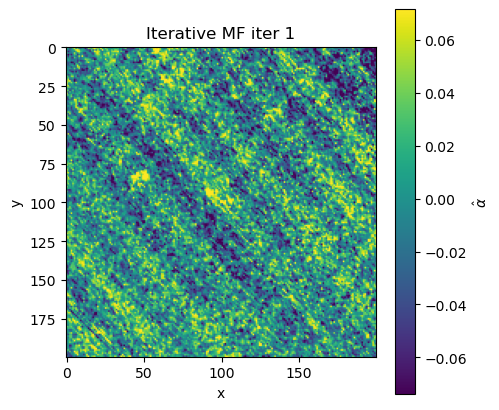

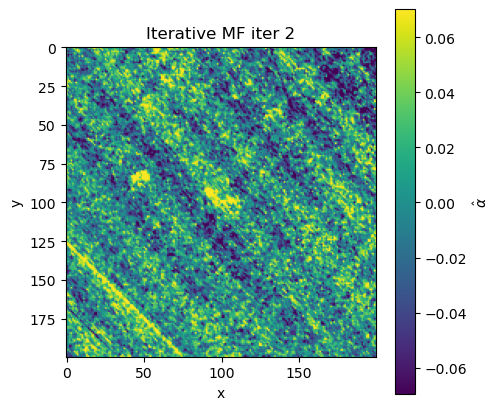

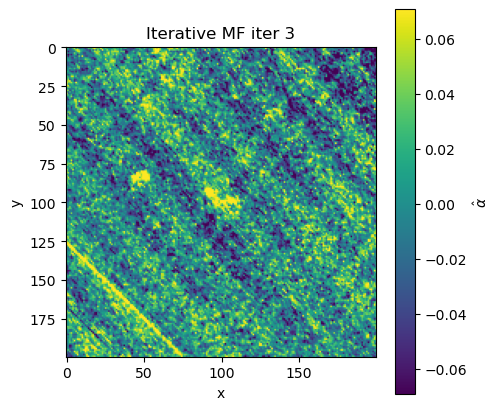

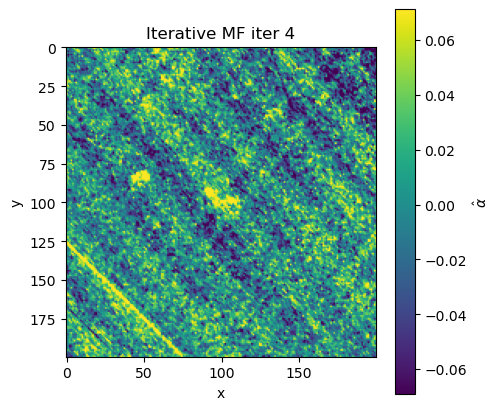

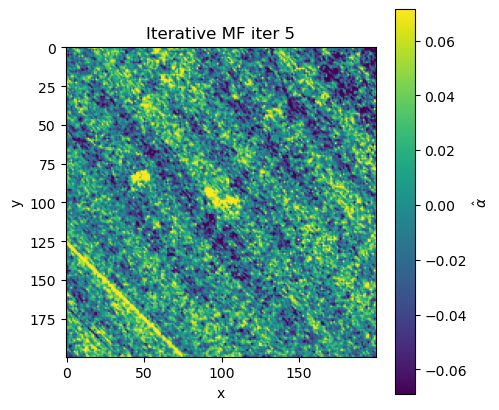

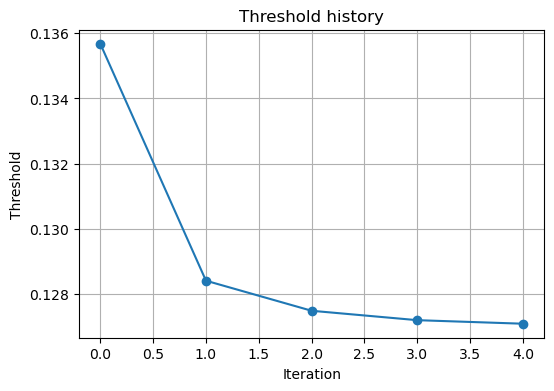

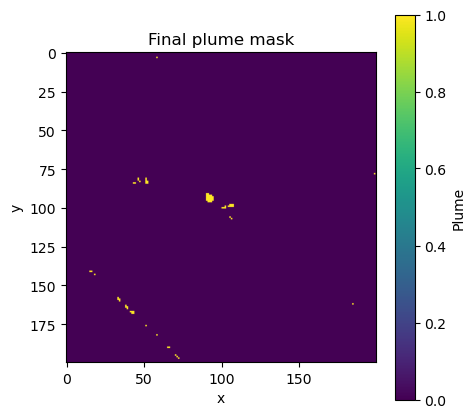

In [28]:
# show the change of alpha map through iterations
alpha_history = result_imf["alpha_history"]

for k, alpha_k in enumerate(alpha_history):
    plot_alpha_map(
        alpha_k,
        title=f"Iterative MF iter {k + 1}",
        vmin=np.nanpercentile(alpha_k, 2),
        vmax=np.nanpercentile(alpha_k, 98)
    )
# show the change of background mask through iterations
plt.figure(figsize=(6, 4))
plt.plot(result_imf["threshold_history"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("Threshold")
plt.title("Threshold history")
plt.grid(True)
plt.show()

# show the final plume mask from iterative MF
plt.figure(figsize=(5, 5))
plt.imshow(plume_imf_mask, origin="upper")
plt.title("Final plume mask")
plt.colorbar(label="Plume")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [17]:
def plot_step5_thresholding(alpha_map, valid_mask, plume_mask, threshold):
    alpha_values = alpha_map[valid_mask]
    alpha_values = alpha_values[np.isfinite(alpha_values)]

    med = np.nanmedian(alpha_values)
    mad = np.nanmedian(np.abs(alpha_values - med))
    robust_std = 1.4826 * mad

    plt.figure(figsize=(15, 4))

    # 1. alpha map
    plt.subplot(1, 3, 1)
    plt.imshow(
        alpha_map,
        vmin=np.nanpercentile(alpha_values, 2),
        vmax=np.nanpercentile(alpha_values, 98),
        origin="upper"
    )
    plt.colorbar(label="alpha")
    plt.title("MF output alpha map")
    plt.xlabel("x")
    plt.ylabel("y")

    # 2. histogram
    plt.subplot(1, 3, 2)
    plt.hist(alpha_values, bins=100)
    plt.axvline(med, linestyle="--", label="median")
    plt.axvline(threshold, linestyle="-", label="threshold")
    plt.xlabel("alpha")
    plt.ylabel("pixel count")
    plt.title("Histogram of alpha")
    plt.legend()
    plt.grid(True)

    # 3. plume mask
    plt.subplot(1, 3, 3)
    plt.imshow(plume_mask, origin="upper")
    plt.colorbar(label="plume candidate")
    plt.title("Plume candidate mask")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()
    plt.show()

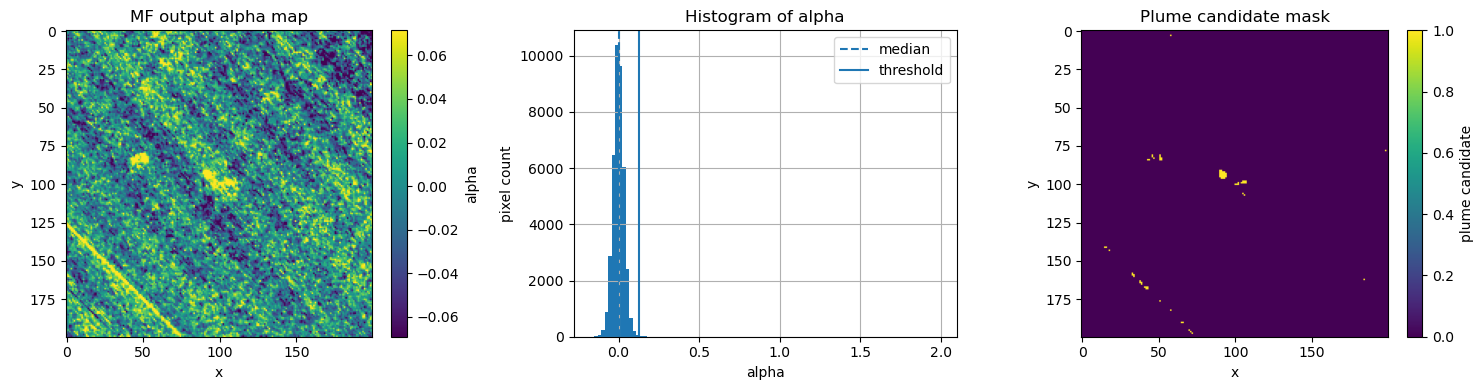

In [18]:
threshold = result_imf["threshold_history"][-1]

plot_step5_thresholding(
    alpha_map=alpha_imf_map,
    valid_mask=valid_mask_2300,
    plume_mask=plume_imf_mask,
    threshold=threshold
)

In [19]:
# save pixel-wise results to CSV
import numpy as np
import pandas as pd
from pathlib import Path
def save_imf_pixel_results_csv(
    alpha_map,
    plume_mask,
    background_mask=None,
    valid_mask=None,
    ys=None,
    xs=None,
    out_csv="imf_pixel_results.csv"
):

    H, W = alpha_map.shape
    row_idx, col_idx = np.indices((H, W))

    if ys is not None:
        y_coord = np.asarray(ys)[row_idx.ravel()]
    else:
        y_coord = row_idx.ravel()

    if xs is not None:
        x_coord = np.asarray(xs)[col_idx.ravel()]
    else:
        x_coord = col_idx.ravel()

    df = pd.DataFrame({
        "row": row_idx.ravel(),
        "col": col_idx.ravel(),
        "y": y_coord,
        "x": x_coord,
        "alpha": alpha_map.ravel(),
        "is_plume": plume_mask.ravel().astype(bool),
    })

    if background_mask is not None:
        df["is_background"] = background_mask.ravel().astype(bool)

    if valid_mask is not None:
        df["is_valid"] = valid_mask.ravel().astype(bool)

    df = df.sort_values("alpha", ascending=False)

    out_csv = Path(out_csv)
    df.to_csv(out_csv, index=False)

    print(f"Saved: {out_csv}")
    print(f"Total pixels: {len(df)}")
    print(f"Plume candidate pixels: {df['is_plume'].sum()}")

    return df

In [ ]:
df_imf = save_imf_pixel_results_csv(
    alpha_map=alpha_imf_map,
    plume_mask=plume_imf_mask,
    background_mask=background_imf_mask,
    valid_mask=valid_mask_2300,
    ys=None,   
    xs=None,   
    out_csv="imf_pixel_results.csv"
)

Saved: imf_pixel_results.csv
Total pixels: 40000
Plume candidate pixels: 407


In [ ]:
# save only plume candidate pixels to a separate CSV
df_plume = df_imf[df_imf["is_plume"]].copy()
df_plume.to_csv("imf_plume_pixels_only.csv", index=False)

print("Saved: imf_plume_pixels_only.csv")
print(df_plume.head(20))


Saved: imf_plume_pixels_only.csv
       row  col    y   x     alpha  is_plume  is_background  is_valid
18692   93   92   93  92  2.519584      True          False      True
18891   94   91   94  91  2.315259      True          False      True
18892   94   92   94  92  2.261243      True          False      True
18691   93   91   93  91  2.161242      True          False      True
19092   95   92   95  92  1.602726      True          False      True
18893   94   93   94  93  1.101269      True          False      True
19093   95   93   95  93  0.898412      True          False      True
18491   92   91   92  91  0.874497      True          False      True
18693   93   93   93  93  0.635473      True          False      True
18690   93   90   93  90  0.615771      True          False      True
19091   95   91   95  91  0.611490      True          False      True
18492   92   92   92  92  0.515105      True          False      True
18890   94   90   94  90  0.462663      True          Fal

In [ ]:
# plot spectrum at selected pixel with background comparison and UAS comparison, and save the spectrum data to CSV
def plot_spectrum_at_yx(
    cube,
    wavelengths,
    y,
    x,
    background_mask=None,
    alpha_map=None,
    uas=None,
    title=None,
    xlim=None,
    save_csv=None
):

    H, W, B = cube.shape

    if not (0 <= y < H and 0 <= x < W):
        raise ValueError(f"(y, x)=({y}, {x}) is outside cube shape H={H}, W={W}.")

    spec = cube[y, x, :]

    if alpha_map is not None:
        alpha_value = alpha_map[y, x]
    else:
        alpha_value = None

# 1. Plot spectrum with background mean comparison
    plt.figure(figsize=(8, 4))
    plt.plot(wavelengths, spec, marker="o", label=f"pixel ({y}, {x})")

    if background_mask is not None:
        bg_mean = np.nanmean(cube[background_mask], axis=0)
        plt.plot(wavelengths, bg_mean, marker="o", label="background mean")

    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Radiance / Reflectance")

    if title is None:
        if alpha_value is None:
            title = f"Spectrum at (y={y}, x={x})"
        else:
            title = f"Spectrum at (y={y}, x={x}), alpha={alpha_value:.4g}"

    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.grid(True)
    plt.legend()
    plt.show()

# 2. Plot difference and ratio to background mean
    if background_mask is not None:
        bg_mean = np.nanmean(cube[background_mask], axis=0)

        diff = spec - bg_mean
        ratio = spec / np.maximum(bg_mean, 1e-12)

        plt.figure(figsize=(8, 4))
        plt.plot(wavelengths, diff, marker="o", label="pixel - background mean")
        plt.axhline(0, linewidth=1)
        plt.xlabel("Wavelength [nm]")
        plt.ylabel("Difference")
        plt.title(f"Difference from background at (y={y}, x={x})")

        if xlim is not None:
            plt.xlim(*xlim)

        plt.grid(True)
        plt.legend()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(wavelengths, ratio, marker="o", label="pixel / background mean")
        plt.axhline(1, linewidth=1)
        plt.xlabel("Wavelength [nm]")
        plt.ylabel("Ratio")
        plt.title(f"Ratio to background at (y={y}, x={x})")

        if xlim is not None:
            plt.xlim(*xlim)

        plt.grid(True)
        plt.legend()
        plt.show()

# 3. Plot comparison to UAS-based target spectrum
    if background_mask is not None and uas is not None:
        bg_mean = np.nanmean(cube[background_mask], axis=0)
        diff = spec - bg_mean

        diff_norm = diff / (np.nanmax(np.abs(diff)) + 1e-12)

        # For absorption, methane target in radiance space is roughly -mu * uas
        target = -bg_mean * uas
        target_norm = target / (np.nanmax(np.abs(target)) + 1e-12)

        plt.figure(figsize=(8, 4))
        plt.plot(wavelengths, diff_norm, marker="o", label="pixel - background, normalized")
        plt.plot(wavelengths, target_norm, marker="o", label="CH4 target, normalized")
        plt.axhline(0, linewidth=1)
        plt.xlabel("Wavelength [nm]")
        plt.ylabel("Normalized value")
        plt.title(f"Difference shape vs CH4 target at (y={y}, x={x})")

        if xlim is not None:
            plt.xlim(*xlim)

        plt.grid(True)
        plt.legend()
        plt.show()

# 4. Save spectrum data to CSV
    if save_csv is not None:
        df = pd.DataFrame({
            "wavelength_nm": wavelengths,
            "spectrum": spec
        })

        if background_mask is not None:
            bg_mean = np.nanmean(cube[background_mask], axis=0)
            df["background_mean"] = bg_mean
            df["difference_from_background"] = spec - bg_mean
            df["ratio_to_background"] = spec / np.maximum(bg_mean, 1e-12)

        if uas is not None:
            df["uas"] = uas

        df["y"] = y
        df["x"] = x

        if alpha_value is not None:
            df["alpha"] = alpha_value

        df.to_csv(save_csv, index=False)
        print(f"Saved: {save_csv}")

    return spec

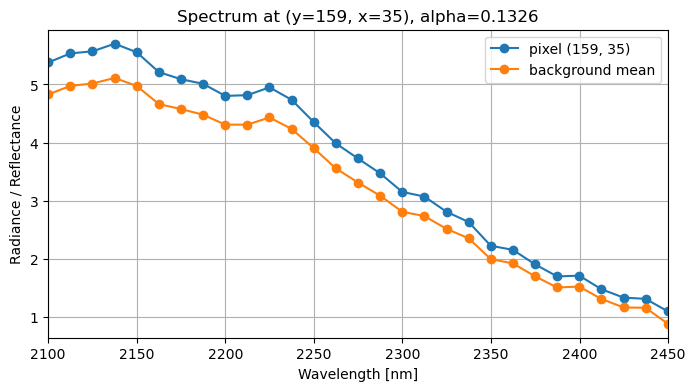

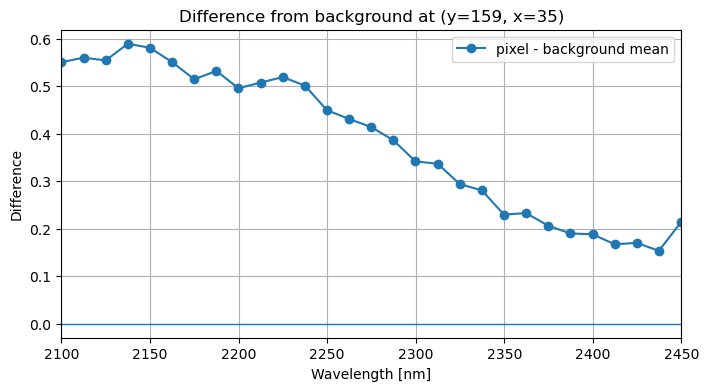

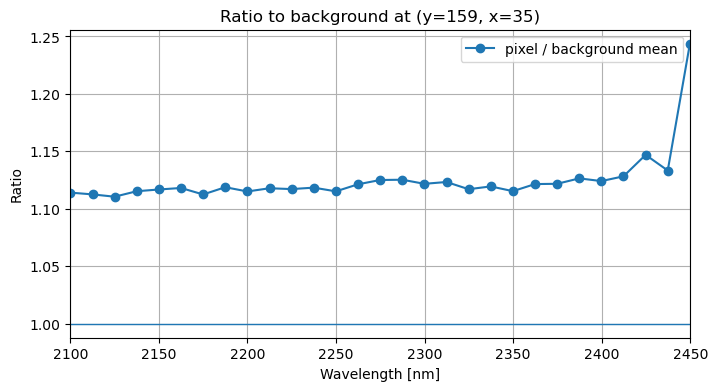

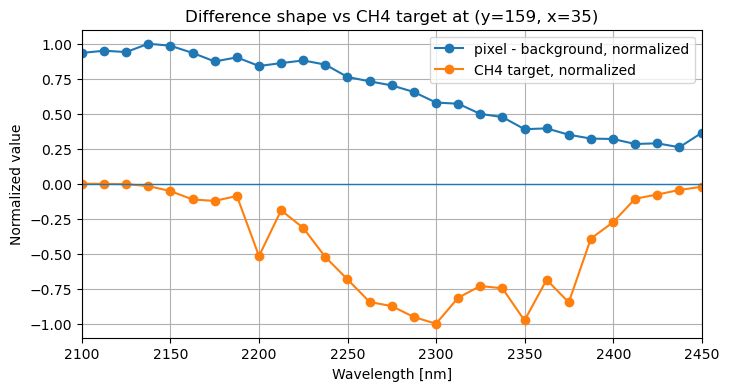

Saved: suspicious_pixel_y159_x35.csv


In [29]:
spec = plot_spectrum_at_yx(
    cube=cube_2300,
    wavelengths=wave_2300,
    y=159,
    x=35,
    background_mask=background_imf_mask,
    alpha_map=alpha_imf_map,
    uas=uas_2300,
    xlim=(2100, 2450),
    save_csv="suspicious_pixel_y159_x35.csv"
)

In [31]:
def plot_pixel_spectrum_yx(cube, wavelengths, y, x, xlim=None, title=None):
    """
    指定した画像座標 (y, x) のスペクトルを表示する。
    y: row方向
    x: col方向
    """

    H, W, B = cube.shape

    if not (0 <= y < H and 0 <= x < W):
        raise ValueError(f"(y, x)=({y}, {x}) is outside image size H={H}, W={W}")

    spec = cube[y, x, :]

    plt.figure(figsize=(8, 4))
    plt.plot(wavelengths, spec, marker="o")
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Radiance / Reflectance")
    
    if title is None:
        title = f"Spectrum at y={y}, x={x}"
    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.grid(True)
    plt.show()

    return spec

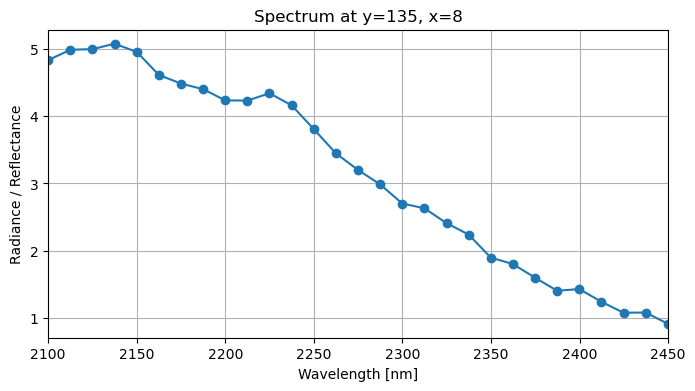

In [34]:
spec = plot_pixel_spectrum_yx(
    cube=cube_2300,
    wavelengths=wave_2300,
    y=135,
    x=8,
    xlim=(2100, 2450)
)

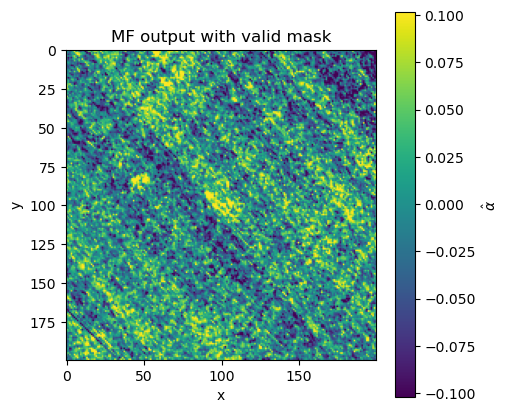

In [21]:
plot_alpha_map(
    alpha_map,
    title="MF output with valid mask",
    vmin=np.nanpercentile(alpha_map, 2),
    vmax=np.nanpercentile(alpha_map, 98)
)

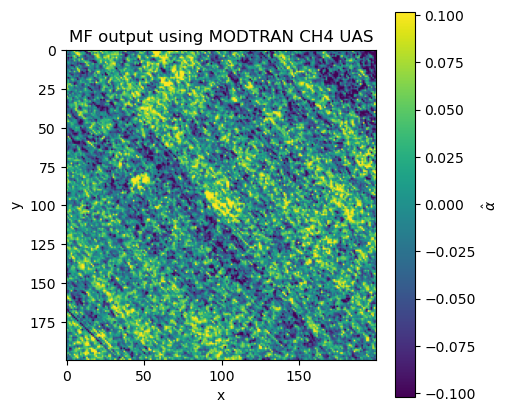

In [20]:
# MF実行
alpha = matched_filter(
    spectra=spectra_2300,
    target=target_2300,
    mu=mu_2300,
    cov=cov_2300
)

H, W, _ = cube_2300.shape
alpha_map = alpha_to_map(alpha, H, W)

plot_alpha_map(
    alpha_map,
    title="MF output using MODTRAN CH4 UAS",
    vmin=np.nanpercentile(alpha_map, 2),
    vmax=np.nanpercentile(alpha_map, 98)
)

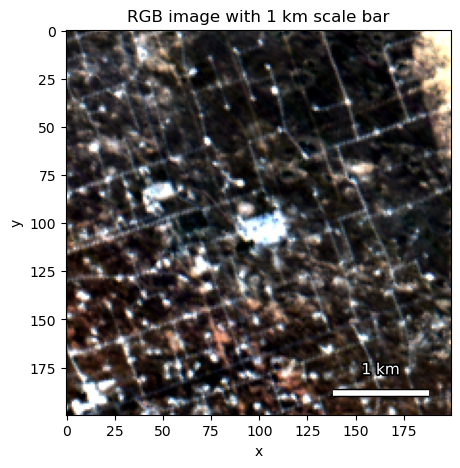

In [22]:
plot_rgb(rgb, title="RGB image with 1 km scale bar")